# 02 · How Inference Happens — one document, end-to-end

**Dissertation:** *SLM vs LLM for Key Information Extraction from financial documents.*

This notebook takes **one real document** and walks it through **every stage of the inference
pipeline** — the exact path `src/runner/run.py` uses to produce the 880-row results table —
so you can *see* how a raw scanned receipt becomes a scored JSON extraction.

```
 raw OCR record
      │  from_dataset_record()        ── Stage 1: normalise to simple JSON (lines + key/values)
      ▼
 simple JSON
      │  build_prompt()               ── Stage 2: assemble the prompt (schema + rules + document)
      ▼
   prompt  ───────────────┐
      │                   │  json_schema_format()   (local models: constrained JSON decoding)
      ▼                   ▼
 MODEL CALL  ── Stage 3 ── three interchangeable backends:
      │   (a) Local SLM  → Ollama (OllamaRunner)          [runs on the M1]
      │   (b) Large LLM  → AWS Bedrock (Converse API)      [the cloud comparison arm]
      │   (c) Replay     → results/runs.jsonl              [saved, offline, deterministic]
      ▼
 raw model text
      │  parse_prediction()           ── Stage 4: robustly extract & validate JSON
      ▼
 predicted fields
      │  score_document()             ── Stage 5: field-level P / R / F1 (type-aware)
      │  efficiency_metrics()         ── Stage 6: latency, tokens/s, peak memory, $ cost
      ▼
   one results row
```

The same `prompt` string is sent to a **0.36 B SLM** and a **120 B LLM** alike — the only thing
that changes is the backend. That is what makes the small-vs-large comparison fair.

## 0 · Setup
Bootstrap the repo path and import the project's real pipeline functions.

In [1]:
import sys, os, json
from pathlib import Path

here = Path.cwd()
REPO = next((p for p in [here, *here.parents] if (p / "src").is_dir() and (p / "config").is_dir()), here)
sys.path.insert(0, str(REPO))
print("repo root:", REPO)

import pandas as pd
import matplotlib.pyplot as plt

from src.config import load_config
from src.data.gt import load_test_records, schema_for_record, align_gold, few_shot_pool, load_test_set
from src.data.preprocess import from_dataset_record
from src.prompts.builder import build_prompt, json_schema_format, field_spec
from src.eval.parse import parse_prediction
from src.eval.metrics import score_document
from src.eval.efficiency import efficiency_metrics
from src.models.registry import build_runners, model_meta
from src.runner.results_store import load_rows

pd.set_option("display.max_colwidth", 100)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

cfg = load_config()
META = model_meta(cfg)
MAX_LINES = cfg["conditions"].get("max_input_lines")
print("max_input_lines =", MAX_LINES, "| structured_output =", cfg["ollama"].get("structured_output"))

repo root: /Users/azharali/Desktop/Projects/slm-llm/slm-vs-llm-kie


max_input_lines = 120 | structured_output = True


## Stage 0 · Pick one document

We use SROIE receipt **132** — the same document the on-stage demo opens with. It's a clean
receipt, so the pipeline is easy to follow; the *identical* code runs on the long Kleister
reports too.

In [2]:
records = load_test_records(cfg)
DOC_ID = "132"
rec = next(r for r in records if r["doc_id"] == DOC_ID)

schema = schema_for_record(cfg, rec)
gold = align_gold(rec.get("gold", {}), schema)

print("dataset:", rec["dataset"], "| doc_id:", rec["doc_id"], "| raw keys:", list(rec.keys()))
print("\nGOLD (what a perfect model should return):")
print(json.dumps(gold, indent=2, ensure_ascii=False))

dataset: sroie | doc_id: 132 | raw keys: ['doc_id', 'dataset', 'schema_name', 'split', 'page', 'words', 'key_values', 'tables', 'gold']

GOLD (what a perfect model should return):
{
  "company": "FARMASI MALURI S/B",
  "date": "02/03/18",
  "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.",
  "total": "79.35"
}


## Stage 1 · OCR record → simple JSON

`from_dataset_record()` turns the raw OCR (SROIE ships *word boxes*; Kleister ships *lines*)
into one uniform shape: `lines`, `key_values`, `tables`. This is the representation everything
downstream is built from.

In [3]:
simple = from_dataset_record(rec)
print(f"n_lines = {len(simple['lines'])} | n_key_values = {len(simple['key_values'])}\n")
print("LINES (first 12):")
for ln in simple["lines"][:12]:
    print("  |", ln)

n_lines = 28 | n_key_values = 0

LINES (first 12):
  | 3180301
  | FARMASI MALURI S/B (587969-U)
  | GST NO: 000342237184 (ID:5033)
  | 23, JIN BURUNG JENTAYU, TMN BUKIT
  | MALURI, KEPONG, 52100 KL.
  | TAX INVOICE
  | CASHIER : POS1N M/C. ID :POS7
  | RECEIPT : 71857936 02/03/18 05:16 PM
  | DESCRIPTION DISC. SUBTOTAL
  | 061558 - **BMS MILK THISTLE
  | 1 X 111.30 36.75 72.35 S
  | 910845 - TRILON-E CRM


## Stage 2 · Build the prompt

`build_prompt()` assembles: the **instruction** (with the exact field list), optional
**few-shot examples** (train-split only), and the **document** block. Two config-controlled
knobs define the experiment conditions:

- **`shot_mode`** — `zero_shot` vs `few_shot` (k=2 examples)
- **`input_variant`** — `lines_only` vs `lines_plus_kv` (also feed detected key/value pairs)

Below is the **complete prompt** a model actually receives for the `zero_shot` / `lines_plus_kv`
condition.

In [4]:
shot_mode, input_variant = "zero_shot", "lines_plus_kv"
prompt = build_prompt(schema, simple, shot_mode, input_variant, max_lines=MAX_LINES)
print(prompt)

You are a precise information-extraction system for financial documents.

You are given the text of a document (its lines, and optionally detected
key/value pairs). Extract the following fields and return them as a single JSON
object with EXACTLY these keys:

- "company" (string, required)
- "date" (date, required)
- "address" (string, required)
- "total" (currency, required)

Rules:
- Return ONLY the JSON object. No explanation, no markdown, no code fences.
- Use the exact key names listed above.
- If a field cannot be found in the document, set its value to null.
- Copy values verbatim from the document where possible; do not invent data.


### Document
LINES:
3180301
FARMASI MALURI S/B (587969-U)
GST NO: 000342237184 (ID:5033)
23, JIN BURUNG JENTAYU, TMN BUKIT
MALURI, KEPONG, 52100 KL.
TAX INVOICE
CASHIER : POS1N M/C. ID :POS7
RECEIPT : 71857936 02/03/18 05:16 PM
DESCRIPTION DISC. SUBTOTAL
061558 - **BMS MILK THISTLE
1 X 111.30 36.75 72.35 S
910845 - TRILON-E CRM
1 X 7.00 7.00 Z
TOT

### Constrained decoding (local models)

For **local** models the runner also passes a JSON schema so Ollama *forces* syntactically
valid JSON with exactly the required keys — this alone eliminated most small-model parse
failures (a key Phase-2 finding). API/Bedrock models get the same prompt without this
enforcement.

In [5]:
rf = json_schema_format(schema)
print("response_format (constrained JSON schema sent to Ollama):")
print(json.dumps(rf, indent=2))

response_format (constrained JSON schema sent to Ollama):
{
  "type": "object",
  "properties": {
    "company": {
      "type": "string"
    },
    "date": {
      "type": "string"
    },
    "address": {
      "type": "string"
    },
    "total": {
      "type": "string"
    }
  },
  "required": [
    "company",
    "date",
    "address",
    "total"
  ]
}


### (Aside) the few-shot variant

Switching `shot_mode="few_shot"` prepends `k=2` worked examples drawn from the **train** split
(never the test set). We show only the length delta here to keep the output short.

In [6]:
ex = few_shot_pool(cfg, rec, {s["doc_id"] for s in load_test_set(cfg)["doc_ids"]}, cfg["conditions"]["few_shot_k"])
fs_prompt = build_prompt(schema, simple, "few_shot", input_variant, examples=ex, max_lines=MAX_LINES)
print(f"zero-shot prompt: {len(prompt):>6} chars")
print(f"few-shot  prompt: {len(fs_prompt):>6} chars  (+{len(fs_prompt)-len(prompt)} from {len(ex)} examples)")

zero-shot prompt:   1392 chars
few-shot  prompt:   2925 chars  (+1533 from 2 examples)


## Stage 3 · The model call — three interchangeable backends

The runner turns `prompt → RunResult(text, latency_s, prompt_tokens, completion_tokens,
peak_mem_mb)`. We show all three backends. Any one produces a `RunResult`; the rest of the
pipeline doesn't care which.

### 3(a) · Local SLM via Ollama — *runs on the M1*

This is the real `OllamaRunner`. If Ollama is running with the model pulled, this cell makes a
**live** call and captures latency + peak memory; otherwise it explains how to enable it and we
fall through to the saved result in 3(c).

In [7]:
LOCAL_MODEL = "gemma3-4b"
live_local = None
try:
    runner = build_runners(cfg, only=[LOCAL_MODEL])[0]
    runner.ensure_available()                      # raises if Ollama down / model not pulled
    live_local = runner.run(prompt, rf)            # constrained JSON decoding
    print(f"LIVE  {LOCAL_MODEL}")
    print(f"  latency   : {live_local.latency_s}s")
    print(f"  tokens    : prompt={live_local.prompt_tokens}  completion={live_local.completion_tokens}")
    print(f"  peak mem  : {live_local.peak_mem_mb} MB")
    print(f"  raw output: {live_local.text[:300]}")
except Exception as exc:
    print(f"[skipped live Ollama call] {type(exc).__name__}: {exc}")
    print("To run live: `ollama serve` then `ollama pull gemma3:4b`. Using saved result below.")

[skipped live Ollama call] RuntimeError: Ollama not reachable at http://localhost:11434. Start it with `ollama serve`. (HTTPConnectionPool(host='localhost', port=11434): Max retries exceeded with url: /api/tags (Caused by NewConnectionError("HTTPConnection(host='localhost', port=11434): Failed to establish a new connection: [Errno 61] Connection refused")))
To run live: `ollama serve` then `ollama pull gemma3:4b`. Using saved result below.


### 3(b) · Large LLM via **AWS Bedrock** — *the cloud comparison arm*

This is the **inference backend for the large models** in Phase 3. Bedrock is serverless
(no GPU to manage) and metered per token, so calling a 70 B–480 B model costs pennies for this
20-doc benchmark. The function uses the **Converse API** (one call shape for every Bedrock
model — Llama, Qwen, DeepSeek, …). It runs live once you set AWS credentials + enable model
access; otherwise it prints setup guidance and we use the saved LLM result in 3(c).

In [8]:
def bedrock_extract(prompt: str, model_id: str, region: str = "us-east-1"):
    """Send the same KIE prompt to an AWS Bedrock model via the Converse API.

    Returns (text, usage_dict). Wire an entry into the harness as a `type: api`
    model to slot this into the full grid alongside Ollama models.
    """
    import boto3
    client = boto3.client("bedrock-runtime", region_name=region)
    resp = client.converse(
        modelId=model_id,
        messages=[{"role": "user", "content": [{"text": prompt}]}],
        inferenceConfig={"temperature": 0.0, "maxTokens": 512},
    )
    text = resp["output"]["message"]["content"][0]["text"]
    return text, resp["usage"]          # usage: {inputTokens, outputTokens, totalTokens}

BEDROCK_MODEL = "us.meta.llama3-3-70b-instruct-v1:0"   # swap for a Qwen3 / DeepSeek-R1 id
live_bedrock = None
try:
    text, usage = bedrock_extract(prompt, BEDROCK_MODEL)
    live_bedrock = text
    print(f"LIVE  Bedrock {BEDROCK_MODEL}")
    print(f"  tokens    : in={usage['inputTokens']}  out={usage['outputTokens']}")
    print(f"  raw output: {text[:300]}")
except Exception as exc:
    print(f"[skipped live Bedrock call] {type(exc).__name__}: {exc}")
    print("To run live: `pip install boto3`, set AWS creds, and enable the model in the")
    print("Bedrock console (Model access). Using the saved large-LLM result below.")

[skipped live Bedrock call] ModuleNotFoundError: No module named 'boto3'
To run live: `pip install boto3`, set AWS creds, and enable the model in the
Bedrock console (Model access). Using the saved large-LLM result below.


### 3(c) · Replay from saved results — *always works, offline*

For a deterministic demo we can also pull what each model **actually returned** on this document
from `results/runs.jsonl` (880 rows). This is the safe fallback and the source of the comparison
charts later.

In [9]:
rows = load_rows(REPO / "results" / "runs.jsonl")
def saved_row(doc_id, model_id, shot="zero_shot", variant="lines_only"):
    cand = [r for r in rows if r["doc_id"] == doc_id and r["model_id"] == model_id]
    if not cand:
        return None
    for r in cand:                                   # prefer the exact condition
        if r["shot_mode"] == shot and r["input_variant"] == variant:
            return r
    return cand[0]

row_slm = saved_row(DOC_ID, LOCAL_MODEL)
row_llm = saved_row(DOC_ID, "frontier-llm")          # GPT-OSS-120B (DO serverless in Phase 2)
print(f"saved {LOCAL_MODEL} prediction on doc {DOC_ID}:")
print(" ", json.dumps(row_slm["predicted_json"], ensure_ascii=False))
print(f"saved frontier-llm (120B) prediction on doc {DOC_ID}:")
print(" ", json.dumps(row_llm["predicted_json"], ensure_ascii=False))

saved gemma3-4b prediction on doc 132:
  {"company": "FARMASI MALURI S/B", "date": "02/03/18", "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.", "total": "79.35"}
saved frontier-llm (120B) prediction on doc 132:
  {"company": "FARMASI MALURI S/B (587969-U)", "date": "02/03/18", "address": "23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.", "total": "79.35"}


## Stage 4 · Parse — robust JSON extraction

Models don't always emit clean JSON: they wrap it in ```json fences, add a sentence of preamble,
or trail commentary. `parse_prediction()` strips fences, grabs the first balanced `{...}`,
validates it against the schema (every field coerced to `str|None`), and returns a structured
`parse_error` instead of crashing on failure. Here it is surviving a deliberately messy
output:

In [10]:
messy = """Sure! Here is the extracted information:
```json
{ "company": "GARDENIA BAKERIES (KL) SDN BHD", "date": "21-05-2017",
  "address": "LOT 3, JALAN PELABUR 23/1", "total": "RM 38.00", "notes": "ignore me" }
```
Hope this helps!"""
pred, perr = parse_prediction(messy, schema)
print("parsed prediction:", json.dumps(pred, ensure_ascii=False))
print("parse_error      :", perr, "   (extras dropped:", pred.get("_extras"), ")")

parsed prediction: {"company": "GARDENIA BAKERIES (KL) SDN BHD", "date": "21-05-2017", "address": "LOT 3, JALAN PELABUR 23/1", "total": "RM 38.00", "_extras": ["notes"]}
parse_error      : None    (extras dropped: ['notes'] )


## Stage 5 · Score — field-level, type-aware

`score_document()` classifies **each field** into one of five categories, then computes
micro precision / recall / F1. Matching is *type-aware*: `date` ignores format, `currency`
ignores the `£`/`,`, strings are case/space-normalised — so a model isn't punished for writing
`RM 38.00` instead of `38`.

| category | meaning | affects |
|---|---|---|
| **tp** | present & correct | ↑ precision & recall |
| **wrong** | present but wrong value | ↓ both |
| **missing** | field left null but gold had one | ↓ **recall** |
| **hallucinated** | invented a value where gold was empty | ↓ **precision** |
| **tn** | correctly left empty | neutral (counts as exact) |

We score the saved SLM and LLM predictions side by side.

In [11]:
def score_table(model_label, gold, pred):
    sc = score_document(gold, pred, schema)
    df = pd.DataFrame({
        "field": list(sc["per_field"]),
        "gold": [gold.get(f) for f in sc["per_field"]],
        "predicted": [(pred or {}).get(f) for f in sc["per_field"]],
        "category": list(sc["per_field"].values()),
    })
    print(f"\n=== {model_label}  |  P={sc['precision']:.2f}  R={sc['recall']:.2f}  "
          f"F1={sc['f1']:.2f}  exact={sc['exact_match_fields']}/{sc['n_fields']} fields ===")
    display(df)
    return sc

sc_slm = score_table(f"{LOCAL_MODEL} (SLM, 4B)", gold, row_slm["predicted_json"])
sc_llm = score_table("frontier-llm (LLM, 120B)", gold, row_llm["predicted_json"])


=== gemma3-4b (SLM, 4B)  |  P=1.00  R=1.00  F1=1.00  exact=4/4 fields ===


,field,gold,predicted,category
0,company,FARMASI MALURI S/B,FARMASI MALURI S/B,tp
1,date,02/03/18,02/03/18,tp
2,address,"23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.","23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.",tp
3,total,79.35,79.35,tp



=== frontier-llm (LLM, 120B)  |  P=0.75  R=0.75  F1=0.75  exact=3/4 fields ===


,field,gold,predicted,category
0,company,FARMASI MALURI S/B,FARMASI MALURI S/B (587969-U),wrong
1,date,02/03/18,02/03/18,tp
2,address,"23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.","23, JIN BURUNG JENTAYU, TMN BUKIT MALURI, KEPONG, 52100 KL.",tp
3,total,79.35,79.35,tp


## Stage 6 · Efficiency — the other half of the story

Accuracy alone doesn't answer the research question; **cost and speed** do. `efficiency_metrics`
records latency, throughput, peak memory, and (for API/Bedrock models) the dollar cost from token
counts × the price table. This is what lets us say *"the SLM is 0.9× the accuracy at 1/Nth the
cost."*

In [12]:
def eff_row(model_id, r):
    m = META.get(model_id, {})
    return {
        "model": m.get("display", model_id),
        "params_B": m.get("params_b"),
        "type": r.get("model_type"),
        "F1": r.get("f1"),
        "latency_s": r.get("latency_s"),
        "peak_mem_MB": r.get("peak_mem_mb"),
        "cost_usd": r.get("cost_usd"),
    }
pd.DataFrame([eff_row(LOCAL_MODEL, row_slm), eff_row("frontier-llm", row_llm)]).set_index("model")

,params_B,type,F1,latency_s,peak_mem_MB,cost_usd
model,,,,,,
Gemma-3-4B,4.0,local,1.00,13.566,2611.4,0.000000
GPT-OSS-120B,120.0,api,0.75,8.667,NaN,0.000318


## Stage 7 · The whole pipeline as one function

Stages 1–6 are exactly what `run.py` loops over docs × models × conditions. Here it is collapsed
into a single call, run in **replay** mode across the small→large model ladder on this one
document — you can watch F1 climb with size.

In [13]:
LADDER = ["smollm2-360m", "qwen2.5-0.5b", "llama3.2-1b", "gemma2-2b",
          "gemma3-4b", "phi4-mini", "mistral-7b", "gemma4-31b",
          "large-open-llm", "frontier-llm"]

def pipeline_replay(doc_id, model_id):
    r = saved_row(doc_id, model_id)
    if r is None:
        return None
    sc = score_document(gold, r["predicted_json"], schema)   # re-scored live from saved prediction
    m = META.get(model_id, {})
    return {"model": m.get("display", model_id), "params_B": m.get("params_b"),
            "F1": round(sc["f1"], 2), "recall": round(sc["recall"], 2),
            "latency_s": r.get("latency_s"), "cost_usd": r.get("cost_usd")}

walk = pd.DataFrame([x for x in (pipeline_replay(DOC_ID, m) for m in LADDER) if x])
walk

,model,params_B,F1,recall,latency_s,cost_usd
0,SmolLM2-360M,0.36,0.25,0.25,1.677,0.000000
1,Qwen2.5-0.5B,0.50,0.25,0.25,4.087,0.000000
2,Llama-3.2-1B,1.00,0.50,0.50,6.414,0.000000
3,Gemma-2-2B,2.00,0.75,0.75,9.859,0.000000
4,Gemma-3-4B,4.00,1.00,1.00,13.566,0.000000
5,Phi-4-mini,3.80,0.75,0.75,12.992,0.000000
6,Mistral-7B,7.00,0.75,0.75,22.311,0.000000
7,Gemma-4-31B,31.00,0.75,0.75,2.268,0.000188
8,Llama-3.3-70B,70.00,0.50,0.50,8.233,0.000367
9,GPT-OSS-120B,120.00,0.75,0.75,8.667,0.000318


## Stage 8 · Dataset-level comparison — the headline

A single document is anecdote; the study's claim rests on the **mean over the frozen 20-doc
benchmark**. Below we aggregate `runs.jsonl` per model (best condition per doc) and plot the
three axes that answer the research question: **F1 vs size**, **latency vs size**, **cost**.

In [14]:
# Best F1 per (doc, model) across conditions, then mean over all test docs.
df = pd.DataFrame(rows)
df = df[df["error"].isna() | (df["error"] == None)]
best = (df.sort_values("f1", ascending=False)
          .groupby(["doc_id", "model_id"], as_index=False).first())
agg = (best.groupby("model_id")
          .agg(F1=("f1", "mean"), latency_s=("latency_s", "mean"),
               cost_usd=("cost_usd", "mean"), n_docs=("doc_id", "nunique")))
agg["params_B"] = [META.get(m, {}).get("params_b") for m in agg.index]
agg["model"] = [META.get(m, {}).get("display", m) for m in agg.index]
agg = agg.dropna(subset=["params_B"]).sort_values("params_B")
agg[["model", "params_B", "F1", "latency_s", "cost_usd", "n_docs"]].round(3).reset_index(drop=True)

,model,params_B,F1,latency_s,cost_usd,n_docs
0,SmolLM2-360M,0.36,0.469,3.200,0.000,20
1,Qwen2.5-0.5B,0.50,0.506,3.422,0.000,20
2,Gemma-3-1B,1.00,0.553,3.876,0.000,20
3,Llama-3.2-1B,1.00,0.532,4.575,0.000,20
4,Gemma-2-2B,2.00,0.702,13.152,0.000,20
5,Phi-4-mini,3.80,0.654,9.684,0.000,20
6,Gemma-3-4B,4.00,0.712,13.317,0.000,20
7,Mistral-7B,7.00,0.716,32.628,0.000,20
8,Gemma-4-31B,31.00,0.732,4.440,0.001,20
9,Llama-3.3-70B,70.00,0.752,18.342,0.001,20


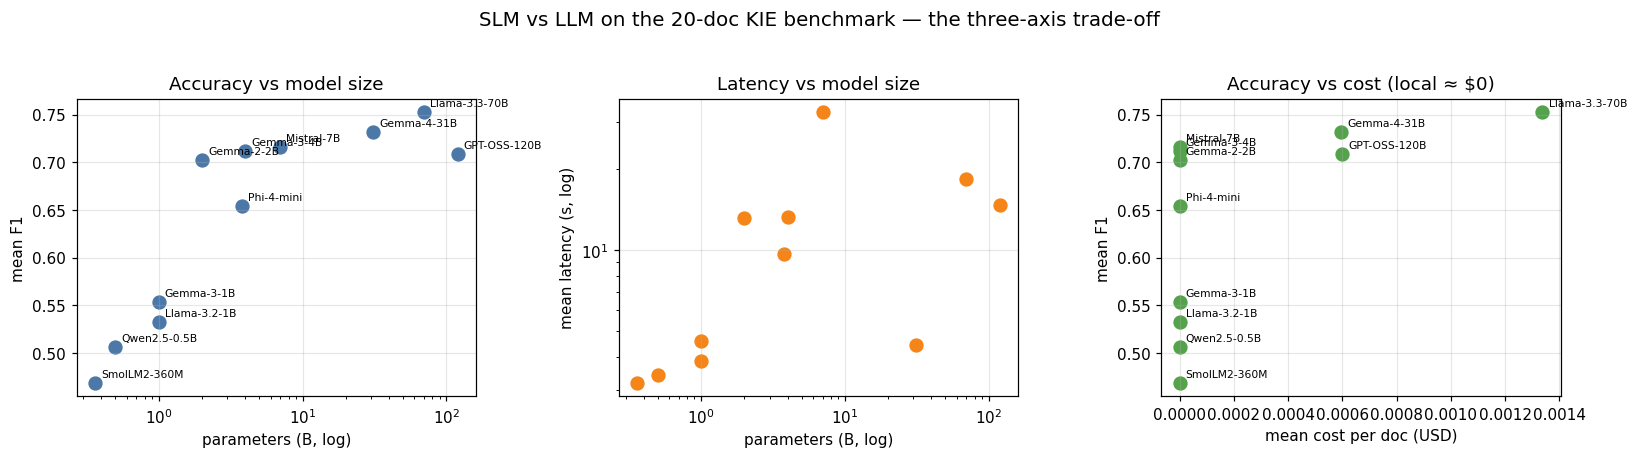

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x = agg["params_B"]

axes[0].scatter(x, agg["F1"], s=70, color="#4C78A8")
for _, r in agg.iterrows():
    axes[0].annotate(r["model"], (r["params_B"], r["F1"]), fontsize=7,
                     xytext=(4, 4), textcoords="offset points")
axes[0].set_xscale("log"); axes[0].set_xlabel("parameters (B, log)"); axes[0].set_ylabel("mean F1")
axes[0].set_title("Accuracy vs model size")

axes[1].scatter(x, agg["latency_s"], s=70, color="#F58518")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("parameters (B, log)"); axes[1].set_ylabel("mean latency (s, log)")
axes[1].set_title("Latency vs model size")

axes[2].scatter(agg["cost_usd"], agg["F1"], s=70, color="#54A24B")
for _, r in agg.iterrows():
    axes[2].annotate(r["model"], (r["cost_usd"], r["F1"]), fontsize=7,
                     xytext=(4, 4), textcoords="offset points")
axes[2].set_xlabel("mean cost per doc (USD)"); axes[2].set_ylabel("mean F1")
axes[2].set_title("Accuracy vs cost (local ≈ $0)")

fig.suptitle("SLM vs LLM on the 20-doc KIE benchmark — the three-axis trade-off", y=1.03, fontsize=13)
plt.tight_layout(); plt.show()

## Takeaways — and where Phase 3 plugs in

- **The pipeline is backend-agnostic.** The identical prompt drives a 0.36 B SLM and a 120 B LLM;
  only the Stage-3 backend swaps. That's what makes the comparison fair.
- **Inference backends by arm:** local SLMs → **Ollama** (on-device, $0/token); large LLMs →
  **AWS Bedrock** Converse API (serverless, pennies for the whole benchmark).
- **Recall is the bottleneck, not hallucination** — even the 120 B model *misses* fields more
  than it invents them. That's the opening for **Phase-3 [P4] regex fallback**.
- **Where fine-tuning lands:** a QLoRA-tuned `phi4-mini-ft` / `mistral-7b-ft` (trained free on
  Colab/Kaggle, exported to GGUF) drops straight back into **Stage 3(a)** as another local model
  — then this same notebook re-scores it against the frozen benchmark for a clean before→after
  delta. That is the Phase-3 headline experiment.